<a href="https://colab.research.google.com/github/ymzprojects/GRPO/blob/main/grpo_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Implémentation de GRPO pour la résolution du jeu de taquin
Ce notebook explore l'application de la méthode GRPO pour la résolution du jeu de taquin de dimension 3x3. L'objectif est d'évaluer les performances de cet algorithme d'apprentissage par renforcement sur un environnement combinatoire dont l'espace d'états est vaste.

La méthode GRPO repose sur l'optimisation d'une politique par rapport à un groupe de trajectoires générées depuis un état initial identique. Cette approche simplifie le calcul de l'avantage en se basant sur les récompenses relatives au sein de ce groupe plutôt que sur un modèle de valeur séparé. Nous cherchons à vérifier si cette simplification maintient une convergence efficace.

L'étude est structurée en deux étapes. La première phase évalue l'apprentissage du modèle uniquement par exploration autonome. La seconde phase introduit des trajectoires expertes générées de manière inversée pour observer si ce guidage accélère et stabilise la convergence de la politique.

In [ ]:
from typing import Callable, Tuple
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import torch.nn.functional as F
import copy
from collections import deque
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Fonctions utilitaires et environnement
Cette section définit la logique du jeu de taquin. Les états sont représentés sous forme de grilles et les actions correspondent aux déplacements possibles de la case vide. Nous y incluons les fonctions de transition, les calculs de récompense basés sur la distance de Manhattan et les générateurs d'états pour l'entraînement.

In [ ]:
def transition(helpers: dict, states: torch.Tensor, actions: torch.Tensor):
    """
    Applique une action sur un lot d'états pour déplacer la case vide.
    Modifie la grille en fonction des coordonnées de déplacement et gère les collisions avec les bords.
    """
    offsets_lookup = helpers["offsets_lookup"]
    device = states.device
    zero_indices = torch.where(states==0)
    b, n, _ = states.shape
    offsets = offsets_lookup[actions]
    r, c = zero_indices[1], zero_indices[2]
    tr, tc = r + offsets[:, 0], c + offsets[:, 1]
    valid = (tr >= 0) & (tr < n) & (tc >= 0) & (tc < n)
    batch_idx = torch.arange(b).to(device)
    batch_idx = batch_idx[valid]
    r_v, c_v = r[valid], c[valid]
    tr_v, tc_v = tr[valid], tc[valid]
    states[batch_idx, r_v, c_v] = states[batch_idx, tr_v, tc_v]
    states[batch_idx, tr_v, tc_v] = 0.0

    return states

def transition_improved(helpers: dict, states: torch.Tensor, actions: torch.Tensor):
    """
    Retourne directement les nouveaux états pré-calculés stockés dans les helpers pour optimiser les appels.
    """
    return helpers["new_states"]

def manhattan_distance(helpers, states):
    """
    Calcule la distance de Manhattan totale entre la disposition actuelle des pièces et la configuration cible.
    """
    n = states.shape[1]
    device = states.device
    target_x = torch.arange(n).view(n, 1).expand(n, n).to(device)
    target_y = torch.arange(n).view(1, n).expand(n, n).to(device)
    states_x = states // n
    states_y = states % n
    dist = torch.abs(target_x.unsqueeze(0) - states_x) + torch.abs(target_y.unsqueeze(0) - states_y)

    return dist.sum(dim=(1, 2)).float()

def count_corrects(helpers, states):
    """
    Compte le nombre de pièces correctement placées à leur position finale pour chaque état du lot.
    """
    n = states.shape[1]
    device = states.device
    target = torch.arange(n * n).view(n, n).to(device)
    return (states == target).view(states.size(0), -1).sum(dim=1).float()

def reward(helpers: dict, states: torch.Tensor, actions: torch.Tensor):
    """
    Calcule la récompense basique après une action en favorisant le rapprochement des pièces vers leur cible.
    """
    offsets_lookup = helpers["offsets_lookup"]
    device = helpers["device"]
    corrects = helpers.get("corrects", torch.zeros(states.shape[0]).to(device))
    zero_indices = torch.where(states==0)
    m, n, _ = states.shape
    batch_idx = torch.arange(m)
    total_slots = n * n - 1
    batch_idx = batch_idx.to(device)
    offsets = offsets_lookup[actions]
    x, y = zero_indices[1], zero_indices[2]
    last_x = x + offsets[:, 0]
    last_y = y + offsets[:, 1]
    valid = (last_x >= 0) & (last_x < n) & (last_y >= 0) & (last_y < n)
    rewards = torch.full(corrects.shape, -1).float()
    rewards = rewards.to(device)

    if valid.any():
        v_idx = batch_idx[valid]
        vx, vy = x[valid], y[valid]
        vlx, vly = last_x[valid], last_y[valid]
        pieces = states[v_idx, vlx, vly].long()
        target_x, target_y = pieces // n, pieces % n
        last_man = torch.abs(vlx - target_x) + torch.abs(vly - target_y)
        man = torch.abs(vx - target_x) + torch.abs(vy - target_y)
        man_reward = torch.where(last_man < man, -1.0, 1.0)
        correct_reward = (man == 0).float() - (last_man == 0).float()
        corrects[v_idx] += correct_reward
        rewards[valid] = (corrects[v_idx] / total_slots) + man_reward

    rewards = torch.where(corrects == total_slots, n**2, rewards).float()
    return rewards

def reward_improved(helpers: dict, states: torch.Tensor, actions: torch.Tensor):
    """
    Fournit un signal de récompense enrichi combinant la réduction de la distance de Manhattan et un bonus de résolution.
    """
    n = states.shape[1]
    old_corrects = count_corrects(helpers, states)
    old_dist = manhattan_distance(helpers, states)
    new_states = transition(helpers, states.clone(), actions)
    new_corrects = count_corrects(helpers, new_states)
    helpers["new_states"] = new_states
    new_dist = manhattan_distance(helpers, new_states)
    progress_reward = old_dist - new_dist
    is_already_solved = (old_dist == 0).float()
    is_solved = (new_dist == 0).float()
    solve_bonus = is_solved * (n ** 2)

    K = (progress_reward  + (new_corrects - old_corrects) * torch.max(old_corrects, new_corrects) - (progress_reward==0).float() + solve_bonus)
    return (is_already_solved==0)*K + is_already_solved*n**2

def generate_shuffled_states(helpers, m, n, p):
    """
    Génère un lot d'états de départ en appliquant une séquence aléatoire de mouvements depuis l'état résolu.
    Conserve l'historique des actions et des états pour la phase d'apprentissage supervisé.
    """
    offsets_lookup = helpers["offsets_lookup"]
    device = helpers["device"]
    target = torch.arange(n * n).view(n, n).float()
    states = target.unsqueeze(0).repeat(m, 1, 1)
    zero_indices = torch.zeros((m, 2), dtype=torch.long)
    target = target.to(device)
    states = states.to(device)
    zero_indices = zero_indices.to(device)
    actions_history = []
    states_history = []

    for _ in range(p):
        actions = torch.randint(0, 4, (m,))
        actions_history.append(actions.clone())
        states_history.append(states.clone())
        states = transition(helpers, states, actions)

    actions_history = torch.stack(actions_history, dim=1)
    states_history = torch.stack(states_history, dim=1)
    current_corrects = (states == target).view(m, -1).sum(dim=1).float()

    return states, zero_indices, current_corrects, actions_history, states_history

def generate_random_states(m, n):
    """
    Crée un lot d'états totalement aléatoires sans garantie qu'ils soient résolubles.
    """
    target = torch.arange(n * n).view(n, n).float()
    noise = torch.rand(m, n * n)
    grids = torch.argsort(noise, dim=1).view(m, n, n).float()

    return grids

# Cœur de l'algorithme GRPO
Nous implémentons ici le déploiement de la politique pour la collecte des trajectoires, le calcul de l'avantage intra-groupe et la fonction de perte GRPO. L'avantage est standardisé sur l'ensemble des trajectoires issues d'un même état initial pour réduire la variance sans nécessiter de réseau critique.

In [ ]:
def run_policy(samples: int,
               steps: int,
               helpers: dict,
               initial_states: torch.Tensor,
               policy: torch.nn.Module,
               transition: Callable[[dict, torch.Tensor, torch.Tensor], torch.Tensor],
               reward: Callable[[dict, torch.Tensor, torch.Tensor], torch.Tensor]) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Exécute la politique sur un nombre défini de pas pour générer un groupe de trajectoires depuis les états initiaux.
    Stocke et renvoie les séquences d'états, d'actions, de récompenses et les probabilités de la politique.
    """
    current_states = initial_states.repeat_interleave(samples, dim=0)

    probs = policy(current_states)
    dist = Categorical(probs)
    current_actions = dist.sample()

    states = torch.zeros(steps, *current_states.shape).to(current_states.device)
    actions = torch.zeros(steps, *current_actions.shape).to(current_states.device)
    rewards = torch.zeros(steps, *current_actions.shape).to(current_states.device)
    predictions = torch.zeros(steps, *probs.shape).to(current_states.device)

    states[0] = current_states.clone()
    actions[0] = current_actions
    rewards[0] = reward(helpers, current_states, current_actions)
    predictions[0] = probs

    current_states = transition(helpers, current_states, current_actions)

    for i in range(steps-1):
        current_predictions = policy(current_states)
        current_dist = Categorical(current_predictions)
        current_actions = current_dist.sample()

        states[i+1] = current_states.clone()
        predictions[i+1] = current_predictions
        actions[i+1] = current_actions
        rewards[i+1] = reward(helpers, current_states, current_actions)

        current_states = transition(helpers, current_states, current_actions)

    nb_initial_states = initial_states.shape[0]
    state_dims = initial_states.shape[1:]

    actions = actions.view(steps, nb_initial_states, samples).permute(1, 2, 0)
    rewards = rewards.view(steps, nb_initial_states, samples).permute(1, 2, 0)

    states = states.view(steps, nb_initial_states, samples, *state_dims).permute(1, 2, 0, 3, 4)
    predictions = predictions.view(steps, nb_initial_states, samples, -1).permute(1, 2, 0, 3)

    return states, actions, rewards, predictions

def advantage(rewards: torch.Tensor, gamma: float) -> torch.Tensor:
    """
    Estime l'avantage d'une action en calculant le rendement actualisé et en le normalisant sur le groupe d'échantillons.
    """
    p = rewards.shape[2]
    samples = rewards.shape[1]
    gamma_p = torch.pow(gamma, torch.arange(p).float()).to(rewards.device)
    shape_broadcast = [1]*rewards.dim()
    shape_broadcast[2] = p
    discounted_rewards = rewards*gamma_p.view(*shape_broadcast)
    discounted_rewards_sum = torch.sum(discounted_rewards, dim=2)
    discounted_rewards_sum_mean = torch.mean(discounted_rewards_sum, keepdim=True, dim=1)
    discounted_rewards_sum_std = torch.std(discounted_rewards_sum, keepdim=True, dim=1, correction=0)

    return ((discounted_rewards_sum - discounted_rewards_sum_mean) / (discounted_rewards_sum_std+ 1e-8)).float()

def J_GRPO(dist: torch.Tensor, old_dist: torch.Tensor, actions: torch.Tensor, advantages: torch.Tensor, epsilon: float):
    """
    Calcule la fonction de coût GRPO avec un ratio d'importance écrêté pour garantir des mises à jour mesurées de la politique.
    """
    index = actions.unsqueeze(-1).long()
    dist_extracted = torch.gather(dist, dim=-1, index=index)
    dist_extracted = dist_extracted.squeeze(-1)
    old_dist_extracted = torch.gather(old_dist, dim=-1, index=index)
    old_dist_extracted = old_dist_extracted.squeeze(-1)

    c1 = torch.exp(torch.log(dist_extracted + 1e-8) - torch.log(old_dist_extracted + 1e-8))
    c2 = c1*advantages
    c3 = torch.clamp(c1, 1-epsilon, 1+epsilon)*advantages
    c4 = torch.min(c2, c3)

    return torch.mean(c4)

# Modèles et mémoire
Le réseau de neurones mappe la configuration de la grille vers une distribution de probabilité sur les quatre actions possibles. Nous définissons une version MLP et une version ResNet pour des architectures plus profondes. Un tampon gère le stockage des trajectoires pour un apprentissage hors ligne par lots.

In [ ]:
def filter(states, actions):
    """
    Filtre les états consécutifs identiques pour retirer les mouvements invalides bloqués contre les murs.
    """
    diffs = (states[1:] != states[:-1]).reshape(states.size(0) - 1, -1).any(dim=1)
    mask = torch.cat([torch.tensor([True], device=states.device), diffs])
    return states[mask], actions[mask]

def reverse_actions(actions):
    """
    Inverse les actions enregistrées pour transformer une trajectoire de mélange en une solution experte.
    """
    rev = torch.tensor([1, 0, 3, 2], device=actions.device)
    return rev[actions]

class DensePuzzlePolicy(nn.Module):
    """
    Réseau de neurones basé sur des couches denses pour inférer l'action optimale à partir de l'état de la grille.
    """
    def __init__(self, grid_size, size):
        super().__init__()
        self.grid_size = grid_size
        self.nb_pieces = grid_size * grid_size

        self.embedding = nn.Linear(self.nb_pieces, size)
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self.nb_pieces * size, size),
            nn.ReLU(),
            nn.Linear(size, size),
            nn.ReLU(),
            nn.Linear(size, size),
            nn.ReLU(),
            nn.Linear(size, 4),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        x = x.long()
        if x.dim() == 3:
            x = x.flatten(1)
        x_one_hot = F.one_hot(x, num_classes=self.nb_pieces).float()
        x_emb = self.embedding(x_one_hot)
        return self.net(x_emb)

class ResidualBlock(nn.Module):
    """
    Bloc résiduel standard pour la conservation de l'information dans les réseaux profonds.
    """
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual
        return F.relu(out)

class PuzzleResNet(nn.Module):
    """
    Réseau convolutionnel résiduel permettant de mieux capter la structure spatiale du jeu.
    """
    def __init__(self, grid_size=3, hidden_dim=64):
        super().__init__()
        self.grid_size = grid_size
        self.nb_pieces = grid_size * grid_size
        self.initial_conv = nn.Conv2d(self.nb_pieces, hidden_dim, kernel_size=3, padding=1)
        self.bn_init = nn.BatchNorm2d(hidden_dim)

        self.res_layers = nn.Sequential(
            ResidualBlock(hidden_dim),
            ResidualBlock(hidden_dim),
            ResidualBlock(hidden_dim)
        )

        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * grid_size * grid_size, 256),
            nn.ReLU(),
            nn.Linear(256, 4),
            nn.Softmax(dim=-1)
        )

    def forward(self, x):
        if x.dim() == 3:
            x = x.long()
            x = F.one_hot(x, num_classes=self.nb_pieces)
            x = x.permute(0, 3, 1, 2).float()
        x = F.relu(self.bn_init(self.initial_conv(x)))
        x = self.res_layers(x)
        return self.fc(self.flatten(x))

class MultiQueueBuffer:
    """
    Structure de stockage FIFO qui conserve les transitions pour réaliser des mises à jour de politique par lots.
    """
    def __init__(self, max_size):
        self.max_size = int(max_size)
        self.queues = {}
        self.current_size = 0

    def append(self, data_dict):
        for key, value in data_dict.items():
            if not isinstance(value, torch.Tensor):
                continue
            data = value.detach()
            if key not in self.queues:
                self.queues[key] = data
            else:
                self.queues[key] = torch.cat([self.queues[key], data], dim=0)

        if self.queues:
            self.current_size = self.queues[next(iter(self.queues))].size(0)

        if self.current_size > self.max_size:
            for key in self.queues:
                self.queues[key] = self.queues[key][-self.max_size:]
            self.current_size = self.max_size

    def get_batches(self, batch_size):
        if self.current_size == 0:
            return
        indices = torch.randperm(self.current_size)
        for i in range(0, self.current_size, batch_size):
            batch_idx = indices[i : i + batch_size]
            yield {key: self.queues[key][batch_idx] for key in self.queues}

    def clear(self):
        self.queues = {}
        self.current_size = 0

    def __len__(self):
        return self.current_size

# Phase 1 - Apprentissage par exploration pure
L'objectif de cette première phase est de tester si le modèle parvient à découvrir des stratégies gagnantes sans aucune intervention extérieure. Nous initialisons les paramètres de l'environnement et de la politique puis lançons la boucle de simulation où l'agent navigue dans l'espace des états et ajuste ses pondérations selon les avantages observés.

In [ ]:
grid_size = 3
batch_size = 16
nb_batches_p1 = 300
start_samples = 64
end_samples = 32
nb_reverse = 64
steps = 64
gamma = 0.99
K_epochs = 1
buffer_batch_size = 512
min_delta = 1e-4
patience = 20
patience_counter = 0
model_complexity = 64
best_r_mean_p1 = -float('inf')
checkpoint_p1 = "best_policy_p1.pth"

offsets_lookup = torch.tensor([[-1, 0], [1, 0], [0, -1], [0, 1]]).to(device)
target = torch.arange(grid_size * grid_size).view(grid_size, grid_size).to(device)
helpers = {"offsets_lookup" : offsets_lookup, "device" : device, "target" : target}

policy_phase1 = DensePuzzlePolicy(grid_size, model_complexity).to(device)
optimizer_p1 = torch.optim.Adam(policy_phase1.parameters(), lr=0.01)

stream = batch_size * max(start_samples, end_samples) * steps
buffer_p1 = MultiQueueBuffer(stream * 2)

losses_p1 = []
means_p1 = []

policy_phase1.train()
pbar_p1 = tqdm(range(nb_batches_p1), desc="Phase 1 - Exploration")

for i in pbar_p1:
    current_samples = int((1 - i / nb_batches_p1) * start_samples + (i / nb_batches_p1) * end_samples)
    buffer_p1.max_size = int(batch_size * current_samples * steps * 2)

    init_states, _, _, _, _ = generate_shuffled_states(helpers, batch_size, grid_size, nb_reverse)
    init_states = init_states.to(device)
    helpers["new_states"] = init_states

    with torch.no_grad():
        s, a, r, old_probs = run_policy(current_samples, steps, helpers, init_states, policy_phase1, transition_improved, reward_improved)
        adv = advantage(r, gamma)

    buffer_p1.append({
        "s": s.flatten(0, 2).to(device),
        "a": a.flatten(0, 2).to(device),
        "adv": adv[..., None].expand(*adv.shape, steps).flatten(0, 2).to(device),
        "old_probs": old_probs.flatten(0, 2).to(device)
    })

    last_loss = 0
    nb_steps_epoch = max(1, len(buffer_p1) // buffer_batch_size)

    for epoch in range(K_epochs):
        optimizer_p1.zero_grad()
        total_loss = 0
        for data in buffer_p1.get_batches(buffer_batch_size):
            new_probs = policy_phase1(data["s"])
            rl_loss = -J_GRPO(new_probs, data["old_probs"], data["a"], data["adv"], epsilon=0.1)
            rl_loss = rl_loss / nb_steps_epoch
            rl_loss.backward()
            total_loss += rl_loss.item()
        optimizer_p1.step()
        last_loss = total_loss

    current_r_mean = r.mean().item()
    pbar_p1.set_postfix({"R_mean": f"{current_r_mean:.4f}", "Loss": f"{last_loss:.4f}"})
    losses_p1.append(last_loss)
    means_p1.append(current_r_mean)

    if current_r_mean > best_r_mean_p1 + min_delta:
        best_r_mean_p1 = current_r_mean
        patience_counter = 0
        torch.save(policy_phase1.state_dict(), checkpoint_p1)
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nArrêt anticipé Phase 1 à l'itération {i}.")
        break

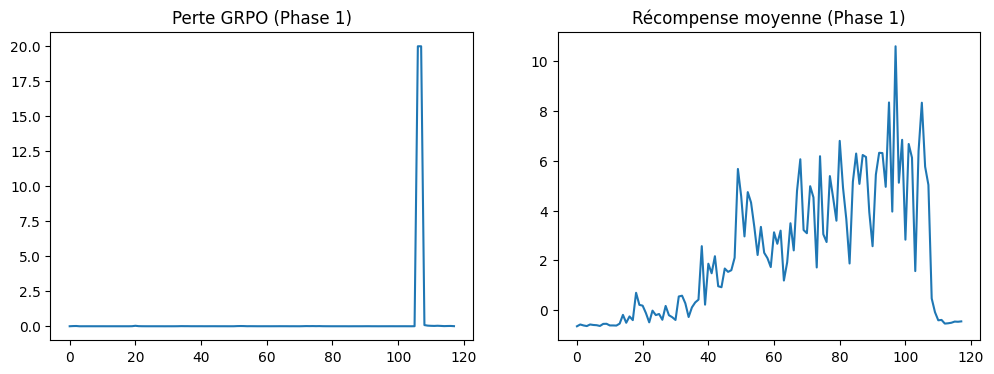

In [ ]:
policy_phase1.load_state_dict(torch.load(checkpoint_p1))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.clip(losses_p1, -10, 20))
plt.title("Perte GRPO (Phase 1)")
plt.subplot(1, 2, 2)
plt.plot(np.clip(means_p1, -10, 20))
plt.title("Récompense moyenne (Phase 1)")
plt.show()

# Phase 2 - Apprentissage guidé par un expert
Nous réinitialisons une nouvelle politique pour quantifier l'impact du guidage. Dans cette phase, nous exploitons la séquence génératrice qui a mélangé le plateau. En inversant cette séquence, nous obtenons une trajectoire parfaite vers la solution. Nous insérons ces données expertes dans le tampon d'apprentissage avec un avantage artificiellement élevé pour forcer le réseau à imiter ces décisions optimales tout en continuant son exploration GRPO classique.

In [ ]:
nb_batches_p2 = 300
patience_counter = 0
best_r_mean_p2 = -float('inf')
checkpoint_p2 = "best_policy_p2.pth"
alpha = 1
alpha_factor = 0.99

policy_phase2 = DensePuzzlePolicy(grid_size, model_complexity).to(device)
optimizer_p2 = torch.optim.Adam(policy_phase2.parameters(), lr=0.01)
buffer_p2 = MultiQueueBuffer(stream * 2)

losses_p2 = []
means_p2 = []

policy_phase2.train()
pbar_p2 = tqdm(range(nb_batches_p2), desc="Phase 2 - Guidage Expert")

for i in pbar_p2:
    current_samples = int((1 - i / nb_batches_p2) * start_samples + (i / nb_batches_p2) * end_samples)
    buffer_p2.max_size = int(batch_size * current_samples * steps * 2)

    init_states, _, _, actions_hist, states_hist = generate_shuffled_states(helpers, batch_size, grid_size, nb_reverse)

    states_teacher = states_hist[:, 1:]
    actions_teacher = reverse_actions(actions_hist[:, :-1])

    teacher_states, teacher_actions = filter(
        states_teacher.flatten(0, 1).flip(0).to(device),
        actions_teacher.flatten(0, 1).flip(0).to(device)
    )

    teacher_adv = torch.full((teacher_actions.shape[0],), 2*alpha).float().to(device)

    with torch.no_grad():
        teacher_old_probs = policy_phase2(teacher_states)

    buffer_p2.append({
        "s": teacher_states,
        "a": teacher_actions,
        "adv": teacher_adv,
        "old_probs": teacher_old_probs
    })

    init_states = init_states.to(device)
    helpers["new_states"] = init_states

    with torch.no_grad():
        s, a, r, old_probs = run_policy(current_samples, steps, helpers, init_states, policy_phase2, transition_improved, reward_improved)
        adv = advantage(r, gamma)

    buffer_p2.append({
        "s": s.flatten(0, 2).to(device),
        "a": a.flatten(0, 2).to(device),
        "adv": adv[..., None].expand(*adv.shape, steps).flatten(0, 2).to(device),
        "old_probs": old_probs.flatten(0, 2).to(device)
    })

    last_loss = 0
    nb_steps_epoch = max(1, len(buffer_p2) // buffer_batch_size)

    for epoch in range(K_epochs):
        optimizer_p2.zero_grad()
        total_loss = 0
        for data in buffer_p2.get_batches(buffer_batch_size):
            new_probs = policy_phase2(data["s"])
            rl_loss = -J_GRPO(new_probs, data["old_probs"], data["a"], data["adv"], epsilon=0.1)
            rl_loss = rl_loss / nb_steps_epoch
            rl_loss.backward()
            total_loss += rl_loss.item()
        optimizer_p2.step()
        last_loss = total_loss

    alpha = alpha * alpha_factor
    current_r_mean = r.mean().item()

    pbar_p2.set_postfix({"R_mean": f"{current_r_mean:.4f}", "Loss": f"{last_loss:.4f}"})
    losses_p2.append(last_loss)
    means_p2.append(current_r_mean)

    if current_r_mean > best_r_mean_p2 + min_delta:
        best_r_mean_p2 = current_r_mean
        patience_counter = 0
        torch.save(policy_phase2.state_dict(), checkpoint_p2)
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print(f"\nArrêt anticipé Phase 2 à l'itération {i}.")
        break

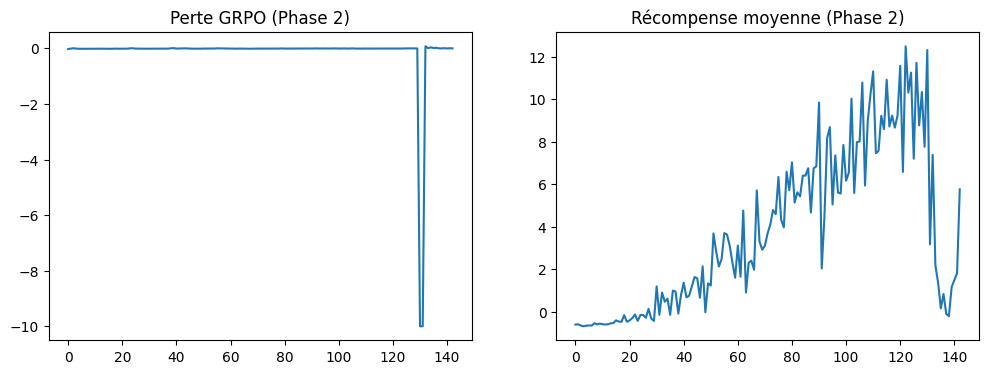

In [ ]:
policy_phase2.load_state_dict(torch.load(checkpoint_p2))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(np.clip(losses_p2, -10, 20))
plt.title("Perte GRPO (Phase 2)")
plt.subplot(1, 2, 2)
plt.plot(np.clip(means_p2, -10, 20))
plt.title("Récompense moyenne (Phase 2)")
plt.show()

# Évaluation et comparaison des performances
Les résultats de l'évaluation mettent en évidence un écart de performance significatif mais pas démesuré entre les deux approches. Cette progression démontre que l'apport de trajectoires expertes facilite grandement la sortie des optima locaux, même si la complexité combinatoire du taquin empêche encore d'atteindre une résolution systématique.

L'analyse des courbes d'apprentissage révèle une instabilité persistante pour les deux méthodes testées. On observe de manière fréquente un phénomène d'effondrement de l'apprentissage où le modèle perd brutalement la totalité de ses acquis après avoir atteint un niveau de performance élevé. Ce crash de la politique est souvent lié à une mise à jour trop agressive qui déstabilise les poids du réseau, rendant le modèle incapable de retrouver ses performances antérieures malgré la poursuite de l'entraînement.

Pour stabiliser l'apprentissage et pallier ces effondrements, plusieurs pistes de recherche peuvent être explorées. Une gestion plus stricte de la contrainte de divergence KL au sein de l'objectif GRPO permettrait de mieux contrôler l'évolution de la politique entre chaque étape d'optimisation. L'ajout d'un mécanisme de relecture d'expérience sélectif permettrait également de conserver les trajectoires les plus réussies dans le temps, évitant ainsi un oubli complet des solutions découvertes.

Une autre piste consiste à ajuster dynamiquement le taux d'apprentissage ou à renforcer la régularisation par l'entropie. Cela garantirait une exploration plus stable sans compromettre la convergence globale. Enfin, l'utilisation d'architectures plus profondes intégrant des couches de normalisation pourrait aider le réseau à mieux supporter les variations brutales de gradients rencontrées lors des phases d'entraînement intensif.

Taux de résolution (Phase 1 - Exploration) : 59.00% (59/100)
Taux de résolution (Phase 2 - Guidé) : 85.00% (85/100)
Taux de résolution (Aléatoire) : 5.00% (5/100)


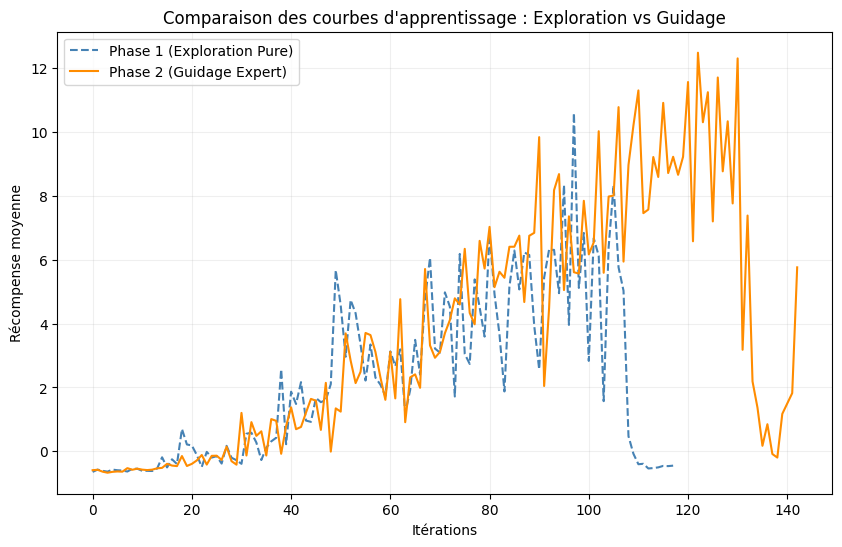

In [ ]:
nb_test_states = 100
target = torch.arange(grid_size * grid_size).view(grid_size, grid_size).float().to(device)
flat_target = target.view(-1)
test_steps = 32

policy_phase1.eval()
policy_phase2.eval()
random_policy = DensePuzzlePolicy(grid_size, 64).to(device)
random_policy.eval()

with torch.no_grad():
    test_states, z_idx, corrects, _, _ = generate_shuffled_states(helpers, nb_test_states, grid_size, test_steps)

    test_helpers = helpers.copy()
    test_helpers['zero_indices'] = z_idx.to(device)
    test_helpers['corrects'] = corrects.to(device)
    test_helpers['new_states'] = test_states.to(device)

    s1, _, _, _ = run_policy(
        samples=1,
        steps=test_steps,
        helpers=test_helpers,
        initial_states=test_states.to(device),
        policy=policy_phase1,
        transition=transition,
        reward=reward
    )
    flat_s1 = s1[:, 0].to(device).reshape(nb_test_states, test_steps, -1)
    solved_p1 = (flat_s1 == flat_target).all(dim=-1).any(dim=-1).sum().item()

    s2, _, _, _ = run_policy(
        samples=1,
        steps=test_steps,
        helpers=test_helpers,
        initial_states=test_states.to(device),
        policy=policy_phase2,
        transition=transition,
        reward=reward
    )
    flat_s2 = s2[:, 0].to(device).reshape(nb_test_states, test_steps, -1)
    solved_p2 = (flat_s2 == flat_target).all(dim=-1).any(dim=-1).sum().item()

    s_rand, _, _, _ = run_policy(
        samples=1,
        steps=test_steps * 2,
        helpers=test_helpers,
        initial_states=test_states.to(device),
        policy=random_policy,
        transition=transition,
        reward=reward
    )
    flat_s_rand = s_rand[:, 0].reshape(nb_test_states, test_steps * 2, -1).to(device)
    solved_rand = (flat_s_rand == flat_target).all(dim=-1).any(dim=-1).sum().item()

    print(f'Taux de résolution (Phase 1 - Exploration) : {solved_p1 / nb_test_states * 100:.2f}% ({solved_p1}/{nb_test_states})')
    print(f'Taux de résolution (Phase 2 - Guidé) : {solved_p2 / nb_test_states * 100:.2f}% ({solved_p2}/{nb_test_states})')
    print(f'Taux de résolution (Aléatoire) : {solved_rand / nb_test_states * 100:.2f}% ({solved_rand}/{nb_test_states})')

plt.figure(figsize=(10, 6))
plt.plot(np.clip(means_p1, -10, 20), label="Phase 1 (Exploration Pure)", color='steelblue', linestyle='--')
plt.plot(np.clip(means_p2, -10, 20), label="Phase 2 (Guidage Expert)", color='darkorange')
plt.xlabel("Itérations")
plt.ylabel("Récompense moyenne")
plt.title("Comparaison des courbes d'apprentissage : Exploration vs Guidage")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()